Plotting Toy Dataset...


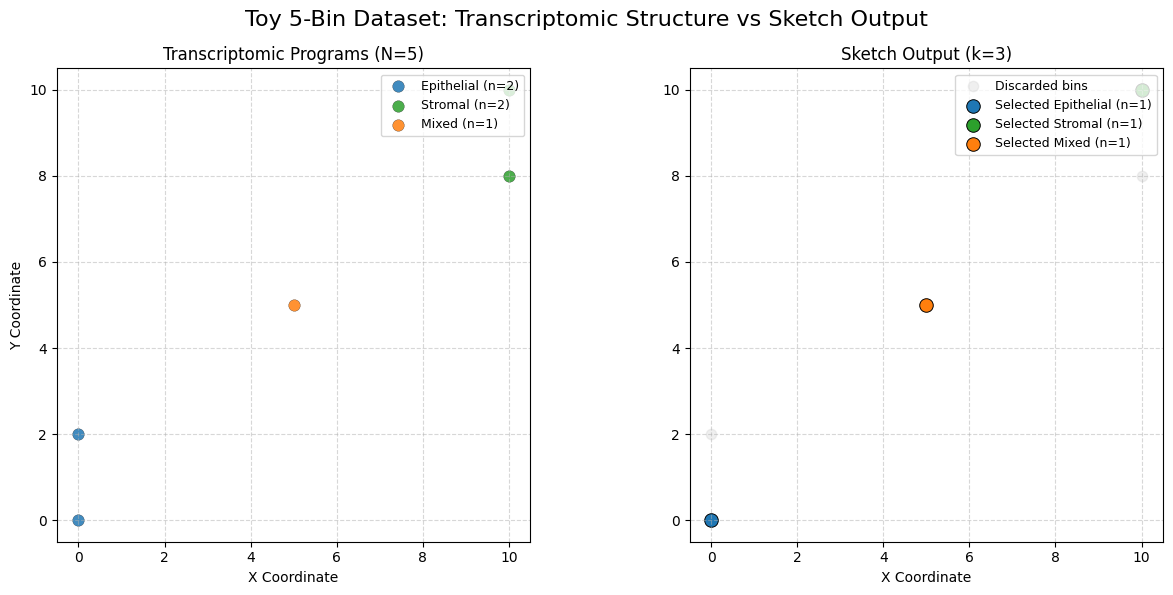

Plotting Grid Dataset...


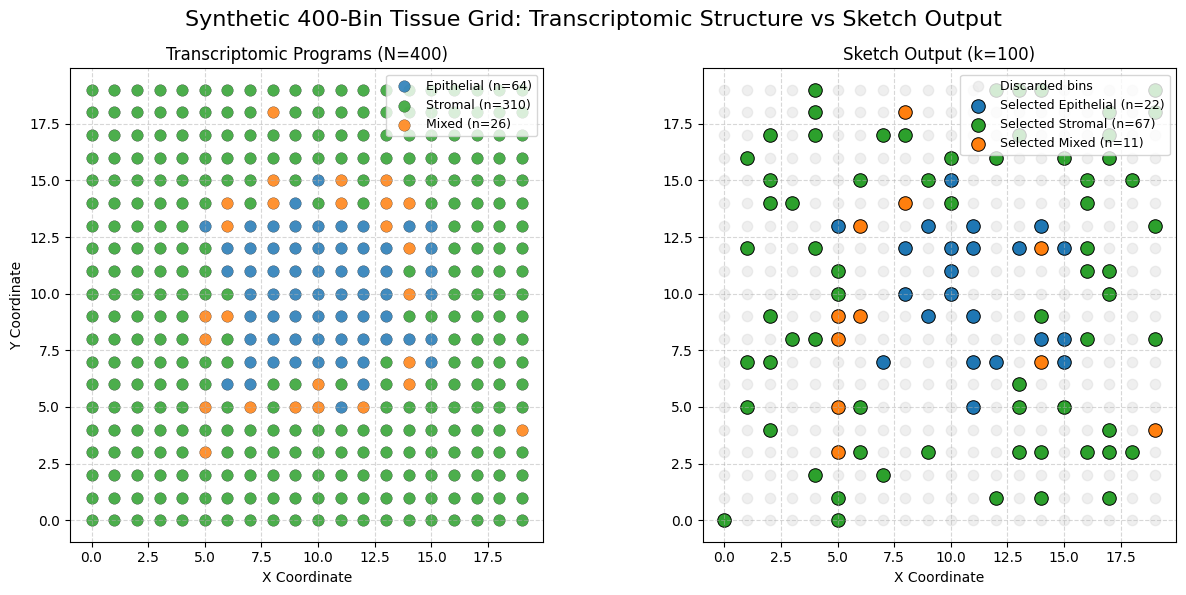

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_sketch_results(csv_filename, title_prefix):
    """Reads the C++ output and generates a 1x2 explanatory visualization."""

    df = pd.read_csv(csv_filename)
    sketched_df = df[df["Is_Sketched"] == 1]
    ignored_df = df[df["Is_Sketched"] == 0]

    # Color map for transcriptomic programs.
    program_colors = {
        "Epithelial": "#1f77b4",
        "Stromal": "#2ca02c",
        "Mixed": "#ff7f0e",
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    fig.suptitle(f"{title_prefix}: Transcriptomic Structure vs Sketch Output", fontsize=16)

    # --- Panel 1: Transcriptomic programs in space ---
    for program, color in program_colors.items():
        subset = df[df["Dominant_Program"] == program]
        if len(subset) == 0:
            continue
        ax1.scatter(
            subset["X_Coordinate"],
            subset["Y_Coordinate"],
            color=color,
            alpha=0.85,
            s=70,
            edgecolor="black",
            linewidth=0.2,
            label=f"{program} (n={len(subset)})",
        )
    ax1.set_title(f"Transcriptomic Programs (N={len(df)})")
    ax1.set_xlabel("X Coordinate")
    ax1.set_ylabel("Y Coordinate")
    ax1.set_aspect("equal", adjustable="box")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc="upper right", fontsize=9)

    # --- Panel 2: Sketch output over transcriptomic context ---
    ax2.scatter(
        ignored_df["X_Coordinate"],
        ignored_df["Y_Coordinate"],
        color="lightgray",
        alpha=0.35,
        s=55,
        label="Discarded bins",
    )

    for program, color in program_colors.items():
        chosen = sketched_df[sketched_df["Dominant_Program"] == program]
        if len(chosen) == 0:
            continue
        ax2.scatter(
            chosen["X_Coordinate"],
            chosen["Y_Coordinate"],
            color=color,
            alpha=1.0,
            s=95,
            edgecolor="black",
            linewidth=0.7,
            label=f"Selected {program} (n={len(chosen)})",
        )

    ax2.set_title(f"Sketch Output (k={len(sketched_df)})")
    ax2.set_xlabel("X Coordinate")
    ax2.set_aspect("equal", adjustable="box")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("Plotting Toy Dataset...")
    plot_sketch_results("toy_dataset_results.csv", "Toy 5-Bin Dataset")

    print("Plotting Grid Dataset...")
    plot_sketch_results("grid_dataset_results.csv", "Synthetic 400-Bin Tissue Grid")